<a href="https://colab.research.google.com/github/Ali13fffff/bank-customer-churn-analysis/blob/main/_churn_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling (7).csv


#Import Libraries

In [60]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder as LE
from xgboost import XGBClassifier as XG
from sklearn.model_selection import GridSearchCV, StratifiedKFold,RandomizedSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay

Load Data

In [61]:
df=pd.read_csv("Churn_Modelling.csv")
print(df.info())
print(df.head())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1   

Cleaning Data

In [62]:
print(df.isnull().sum())
print(df.duplicated().sum())
df=df.drop(columns=["RowNumber","CustomerId","Surname"])
print(df.info())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non

#Creating Engineered Features

In [63]:


df["Age_Group"]=pd.cut(df["Age"],bins=[17,30,44,65,100],labels=["18-30","31-44","45-65","+66"])
df["salary_to_Balance"]=df["EstimatedSalary"]/(df["Balance"]+1)
df["Balance_to_Salary"]=df["Balance"]/(df["EstimatedSalary"]+1)
df["Balance_per_Age"]=df["Balance"]/(df["Age"])
df["Active_older"]=((df["IsActiveMember"]==0) & (df["Age"]>=45)).astype(int)

#Feature Engineering

In [64]:


le = LE()
df['Gender'] = le.fit_transform(df['Gender'])

df = pd.get_dummies(df, columns=['Geography','Age_Group'], drop_first=True, dtype=int)

#Data Splitting

In [65]:
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#Hyperparameter Tuning (RandomizedSearchCV

In [67]:


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    "max_depth": [3, 4, 5, 6, 8, 10,12],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300, 400,600],
'scale_pos_weigh':[2,3,3.5,4]
}

random_search = RandomizedSearchCV(
    XG(random_state=42,),
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

print(f"Best params: {random_search.best_params_}")
print(f"Best F1 Score: {random_search.best_score_}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:57:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "scale_pos_weigh" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best params: {'scale_pos_weigh': 4, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.05}
Best F1 Score: 0.5963906471730196


#XGBoost Hyperparameter Tuning

Classification Report on Test Set:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92      1607
           1       0.74      0.51      0.60       393

    accuracy                           0.87      2000
   macro avg       0.81      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000

ROC-AUC Score: 0.8681



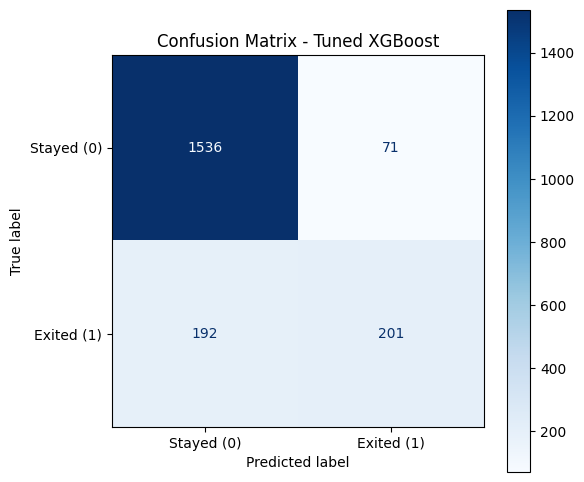

In [68]:



best_model = random_search.best_estimator_


y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]


print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred))


roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}\n")


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Stayed (0)", "Exited (1)"])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
plt.title("Confusion Matrix - Tuned XGBoost")
plt.grid(False)
plt.show()

#Feature Importance

Feature Importance:
              Feature  Importance
12       Active_older    0.489153
16    Age_Group_45-65    0.286315
5       NumOfProducts    0.056212
7      IsActiveMember    0.029336
13  Geography_Germany    0.025654
2                 Age    0.023542
10  Balance_to_Salary    0.014195
1              Gender    0.013885
4             Balance    0.011858
9   salary_to_Balance    0.009707
11    Balance_per_Age    0.006969
14    Geography_Spain    0.006592
0         CreditScore    0.006365
8     EstimatedSalary    0.005784
3              Tenure    0.005686
6           HasCrCard    0.004480
15    Age_Group_31-44    0.004267
17      Age_Group_+66    0.000000


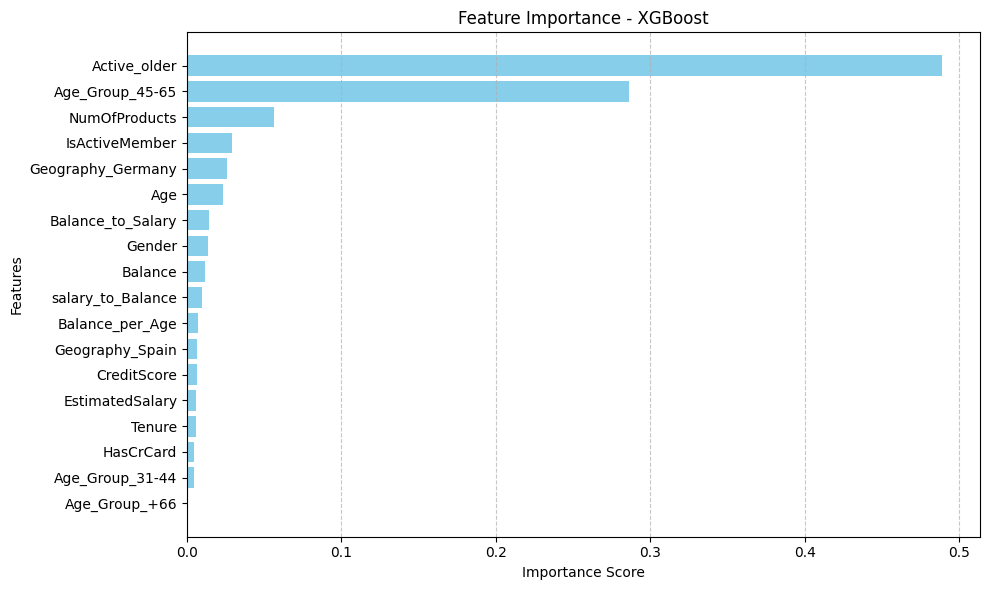

In [69]:


importances = best_model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance:")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#Random Forest Training, Evaluation, and Feature Importance

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Params (RF): {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
Best F1 Score (RF): 0.6248323351947642
              precision    recall  f1-score   support

           0       0.92      0.89      0.90      1607
           1       0.59      0.68      0.63       393

    accuracy                           0.84      2000
   macro avg       0.75      0.78      0.77      2000
weighted avg       0.85      0.84      0.85      2000

ROC-AUC: 0.8653


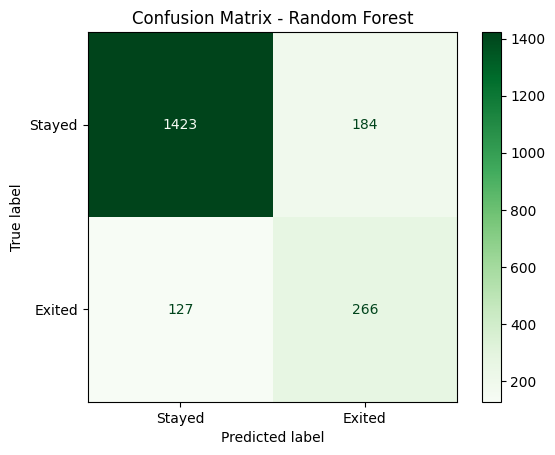

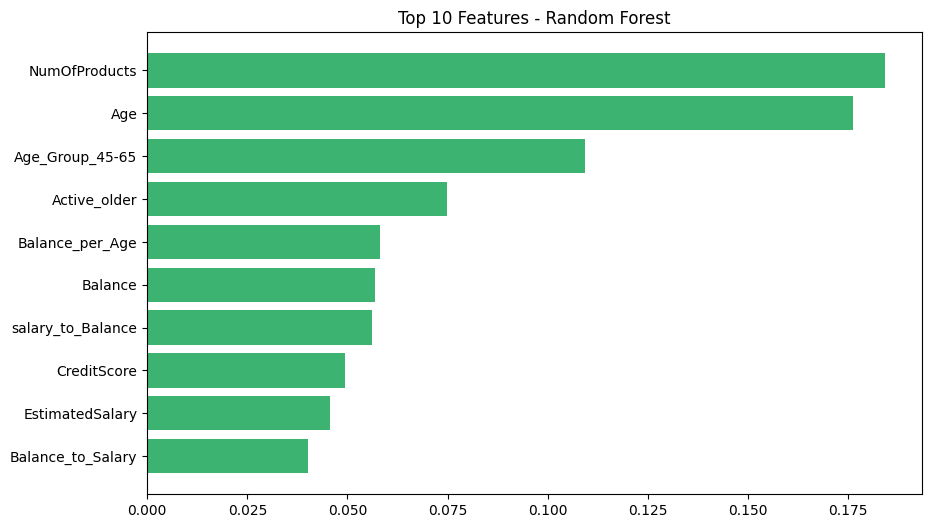

In [70]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=-1)

param_dist_rf = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 8, 10,12],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

cv_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_random_search = RandomizedSearchCV(
    estimator=rf_model,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring="f1",
    cv=cv_rf,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf_random_search.fit(X_train, y_train)

best_rf = rf_random_search.best_estimator_
print(f"Best Params (RF): {rf_random_search.best_params_}")
print(f"Best F1 Score (RF): {rf_random_search.best_score_}")

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Stayed", "Exited"])
disp_rf.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Random Forest")
plt.show()

importances_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importances_rf["Feature"].head(10), importances_rf["Importance"].head(10), color="mediumseagreen")
plt.gca().invert_yaxis()
plt.title("Top 10 Features - Random Forest")
plt.show()